In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    OneHotEncoder, 
    LabelEncoder, 
    OrdinalEncoder, 
    PowerTransformer, 
    StandardScaler,
    MinMaxScaler
)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    balanced_accuracy_score, 
    f1_score, 
    ConfusionMatrixDisplay
)


## Load Data

In [2]:
us_visa_data = pd.read_csv("EasyVisa.csv")
us_visa_data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


## Data Cleaning

During initial analysis we found that that the `case_id` has only unique values therefore high variance which is normal given that it's the unique identifier of each visa application however this feature is not useful for modeling so it can be safely removed. We also saw that sone of the records have negative values for the `no_of_employees` feature. It seems that this is a mistake during data collection since there is no pattern in the data that can suggest other reason. These records are very few so they can be safely removed too. 

In [3]:
us_visa_data = us_visa_data.drop(columns=["case_id"])

negative_no_employees = us_visa_data[us_visa_data["no_of_employees"] < 0 ].index
us_visa_data = us_visa_data.drop(negative_no_employees)

us_visa_data.shape

(25447, 11)

## Feature Engineering

In [4]:
from datetime import date

today_date = date.today()
current_year = today_date.year

# Creating a campany age feature to facilitate any future models
us_visa_data["company_age"] = current_year - us_visa_data["yr_of_estab"] 
us_visa_data = us_visa_data.drop(columns=["yr_of_estab"])

us_visa_data.shape

(25447, 11)

## Preprocessing

Before training any machine learning model the data has to be in a suitable format for this task. Machine learning models work only with numbers and don't know what to do with categories so categorical features have to be encoded in some way. Also some models don't work well with numerical features that are on vastly different scales and those features have to be rescaled to some range.

In [5]:
numeric_features = [feature for feature in us_visa_data.columns if us_visa_data[feature].dtype != 'str']
ohe_features = [
    "continent", 
    "has_job_experience", 
    "requires_job_training", 
    "region_of_employment", 
    "unit_of_wage", 
    "full_time_position"
]

# The categories inside education_of_employee have an inherent order 
# (e.g. High School education is lower than Bachelor's degree etc.)
ordinal_features = ["education_of_employee"]
target_column = "case_status"
education_categories = ["High School", "Bachelor's", "Master's", "Doctorate"]

numeric_pipeline = Pipeline(steps=[
    # Makes skewed distributions more Gaussian-like. Many algorithms assume normally distributed data
    ("log_transform", PowerTransformer(standardize=False)),
    
    # Scales the data to be in the range between 0 and 1
    # Suitable for normally distributed data with no outliers 
    ("scale", MinMaxScaler())])

ohe_pipeline = Pipeline([
    # Creates a new binary column for each category
    ("ohe", OneHotEncoder(sparse_output=False, drop="first"))
])

ordinal_pipeline = Pipeline(steps=[
    ("encode", OrdinalEncoder(categories=[education_categories]))
]) 

transformer = ColumnTransformer([
    ("numeric_pipeline", numeric_pipeline, numeric_features),
    ("ohe_pipeline", ohe_pipeline, ohe_features),
    ("ordinal_pipeline", ordinal_pipeline, ordinal_features)
])

# Encoding the target column as binary labels (0 -> Denied, 1 -> Certified)
us_visa_data["case_status"] = us_visa_data["case_status"].apply(lambda row: 0 if row == "Denied" else 1)

In [6]:
us_visa_data["case_status"]

0        0
1        1
2        0
3        0
4        1
        ..
25475    1
25476    1
25477    1
25478    1
25479    1
Name: case_status, Length: 25447, dtype: int64

## Model Building

### Train, Validation and Test Splits

In [7]:
visa_attributes = us_visa_data.drop(columns=target_column) # Input features
visa_target = us_visa_data[target_column] # Target column

attributes_train_and_val, attributes_test, target_train_and_val, target_test = train_test_split(
    visa_attributes, 
    visa_target, 
    test_size=0.2, 
    stratify=visa_target,
    random_state=42
)

attributes_train, attributes_val, target_train, target_val = train_test_split(
    attributes_train_and_val, 
    target_train_and_val,
    test_size=4000,
    stratify=target_train_and_val, 
    random_state=42
)

print(attributes_train_and_val.shape, attributes_test.shape, target_train_and_val.shape, target_test.shape)
print(attributes_train.shape, attributes_val.shape, target_train.shape, target_val.shape)

(20357, 10) (5090, 10) (20357,) (5090,)
(16357, 10) (4000, 10) (16357,) (4000,)


In [8]:
test_set = pd.concat([attributes_test, target_test], axis=1)
test_set.to_csv("test.csv")

del test_set
del attributes_test
del target_test

### Evaluation Metrics

Given the imbalanced dataset some suitable metrics for this case are __balanced accuracy__ and __f1_score__

- **balanced accuracy**: the average recall for each class. This is our main metric
- **f1_score**: the harmonic mean of precision and recall. It is suitable for cases where precision and recall are of equal importance

### Dummy Model

The first model is a simple dummy model that predicts the most common class. It has high bias as expected since it doesn't learn anything interesting from the data besides the most common label. It achived a balanced accuracy score of 50% and  a f1 score of 80%.

In [9]:
base_pipeline = Pipeline([
    ("transform", transformer),
    # A simple model with no learning capacity to serve as baseline for later comparison 
    ("model", DummyClassifier(strategy="most_frequent"))
])

base_pipeline.fit(attributes_train, target_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('ohe_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [10]:
train_accuracy = balanced_accuracy_score(target_train, base_pipeline.predict(attributes_train))
train_f1_score = f1_score(target_train, base_pipeline.predict(attributes_train))

print(f"Train set balanced accuracy score: {train_accuracy:.4f}")
print(f"Train set f1 score: {train_f1_score:.4f}")

Train set balanced accuracy score: 0.5000
Train set f1 score: 0.8010


### Linear Support Vector Classifier

The next model is a Support Vector Classifier. It performs better than the baseline but also seems to have high bias. The results for both training and validation sets and both metrics are very similar which indicates that probably the default regulariation strenght is too high.

In [11]:
svm_pipeline = Pipeline([
    ("transform", transformer),
    # A more complex linear model with a good performance both for categorical and numeric features
    ("model", LinearSVC(random_state=42))
])

svm_pipeline.fit(attributes_train, target_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('ohe_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [12]:
train_accuracy = balanced_accuracy_score(target_train, svm_pipeline.predict(attributes_train))
train_f1_score = f1_score(target_train, svm_pipeline.predict(attributes_train))

print(f"Train set balanced accuracy score: {train_accuracy:.4f}")
print(f"Train set f1 score: {train_f1_score:.4f}")

Train set balanced accuracy score: 0.6543
Train set f1 score: 0.8148


In [13]:
val_accuracy = balanced_accuracy_score(target_val, svm_pipeline.predict(attributes_val))
val_f1_score = f1_score(target_val, svm_pipeline.predict(attributes_val))

print(f"Validation set balanced accuracy score: {val_accuracy:.4f}")
print(f"Validation set f1 score: {val_f1_score:.4f}")

Validation set balanced accuracy score: 0.6634
Validation set f1 score: 0.8208


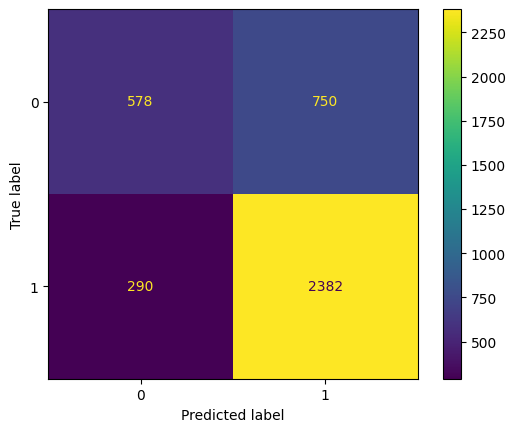

In [14]:
ConfusionMatrixDisplay.from_estimator(svm_pipeline, attributes_val, target_val)
plt.show()

### Decision Tree Classifier

The next model is a DecisionTreeClassifier. This model perform better than the LinearSVC model but has high variance and overfits on the training data and doesn't perform well on the validation data. This happens because an unregularized tree can grow infinately deep untill the leaf nodes at the bottom level contain only pure smaples and  absolutely perfect classification. 

In [15]:
tree_pipeline = Pipeline([
    ("transform", transformer),
    # A more complex model with a good performance on data with mainly categorical features.
    # Most probably will overfit the training data
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(attributes_train, target_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('ohe_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [16]:
train_accuracy = balanced_accuracy_score(target_train, tree_pipeline.predict(attributes_train))
train_f1_score = f1_score(target_train, tree_pipeline.predict(attributes_train))

print(f"Train set balanced accuracy score: {train_accuracy:.4f}")
print(f"Train set f1 score: {train_f1_score:.4f}")

Train set balanced accuracy score: 1.0000
Train set f1 score: 1.0000


In [17]:
val_accuracy = balanced_accuracy_score(target_val, tree_pipeline.predict(attributes_val))
val_f1_score = f1_score(target_val, tree_pipeline.predict(attributes_val))

print(f"Validation set balanced accuracy score: {val_accuracy:.4f}")
print(f"Validation set f1 score: {val_f1_score:.4f}")

Validation set balanced accuracy score: 0.5981
Validation set f1 score: 0.7305


### Random Forest Classifier

The next model is a Random Forest Classifier. It also has high variance and overfits to the training data and doesn't perform well on the validation data. 

In [22]:
forest_pipeline = Pipeline([
    ("transform", transformer),
    
    # An ensamble model made of multiple decision trees trained on different subsets of the training data
    # Has a lower chance of overfitting to the training data.
    ("model", RandomForestClassifier(random_state=42))
])

forest_pipeline.fit(attributes_train, target_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('ohe_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [23]:
train_accuracy = balanced_accuracy_score(target_train, forest_pipeline.predict(attributes_train))
train_f1_score = f1_score(target_train, forest_pipeline.predict(attributes_train))

print(f"Train set balanced accuracy score: {train_accuracy:.4f}")
print(f"Train set f1 score: {train_f1_score:.4f}")

Train set balanced accuracy score: 1.0000
Train set f1 score: 1.0000


In [24]:
val_accuracy = balanced_accuracy_score(target_val, forest_pipeline.predict(attributes_val))
val_f1_score = f1_score(target_val, forest_pipeline.predict(attributes_val))

print(f"Validation set balanced accuracy score: {val_accuracy:.4f}")
print(f"Validation set f1 score: {val_f1_score:.4f}")

Validation set balanced accuracy score: 0.6688
Validation set f1 score: 0.8061
